Models:
- Logistic Regression
- Random Forests
- XGBoost / LightGBM

Feature Importance: Global and Local (SHAP)

## Sentiment Analysis & Vocabulary Level explained

#### Sentiment Analysis

$\text{Compound Score} = \frac{x}{\sqrt{x^2 + \alpha}}$, $\alpha = 15$

$x$ is the sum of the scores for all the words in the blurb. A word's score is high when it is assoociated with a positive sentiment and low (negative) when associated with a negative sentiment. This score is adjusted depending on the context in which the word is located.

#### Vocabulary Level

$\text{Readability Score} = 206.835 - 1.015 \left( \frac{\text{total words}}{\text{total sentences}} \right) - 84.6 \left( \frac{\text{total syllables}}{\text{total words}} \right)$

## Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
import seaborn as sns
import matplotlib.colors as mcolors
from IPython.display import display
from matplotlib.colors import hex2color

import warnings
warnings.filterwarnings('ignore')

/users/eleves-b/2022/louis.martino/TA_Group-Project/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train, df_val, df_test = pd.read_csv("../data/features/train.csv"), pd.read_csv("../data/features/val.csv"), pd.read_csv("../data/features/test.csv")

In [3]:
with open("../data/features/features_scale.txt", "r") as f:
    features_scale = [line.strip() for line in f.readlines()]

with open("../data/features/features_no_scale.txt", "r") as f:
    features_no_scale = [line.strip() for line in f.readlines()]

## Data Preparation

In [4]:
df_train = pd.concat([df_train, df_val], ignore_index=True)

X_train = df_train[features_scale + features_no_scale]
y_train = df_train["target"]

# X_val = df_val[features_scale + features_no_scale]
# y_val = df_val["target"]
X_test = df_test[features_scale + features_no_scale]
y_test = df_test["target"]

In [5]:
scaler = StandardScaler()

# Fit & Transform on train
X_train_scaled_num = scaler.fit_transform(X_train[features_scale])
X_train_scaled_num = pd.DataFrame(X_train_scaled_num, columns=features_scale, index=X_train.index)

# Transform (only) on val
# X_val_scaled_num = scaler.transform(X_val[features_scale])
# X_val_scaled_num = pd.DataFrame(X_val_scaled_num, columns=features_scale, index=X_val.index)
X_test_scaled_num = scaler.transform(X_test[features_scale])
X_test_scaled_num = pd.DataFrame(X_test_scaled_num, columns=features_scale, index=X_test.index)

# Gathering all features together
X_train_final = pd.concat([X_train_scaled_num, X_train[features_no_scale]], axis=1)
#X_val_final = pd.concat([X_val_scaled_num, X_val[features_no_scale]], axis=1)
X_test_final = pd.concat([X_test_scaled_num, X_test[features_no_scale]], axis=1)

### Correlation study

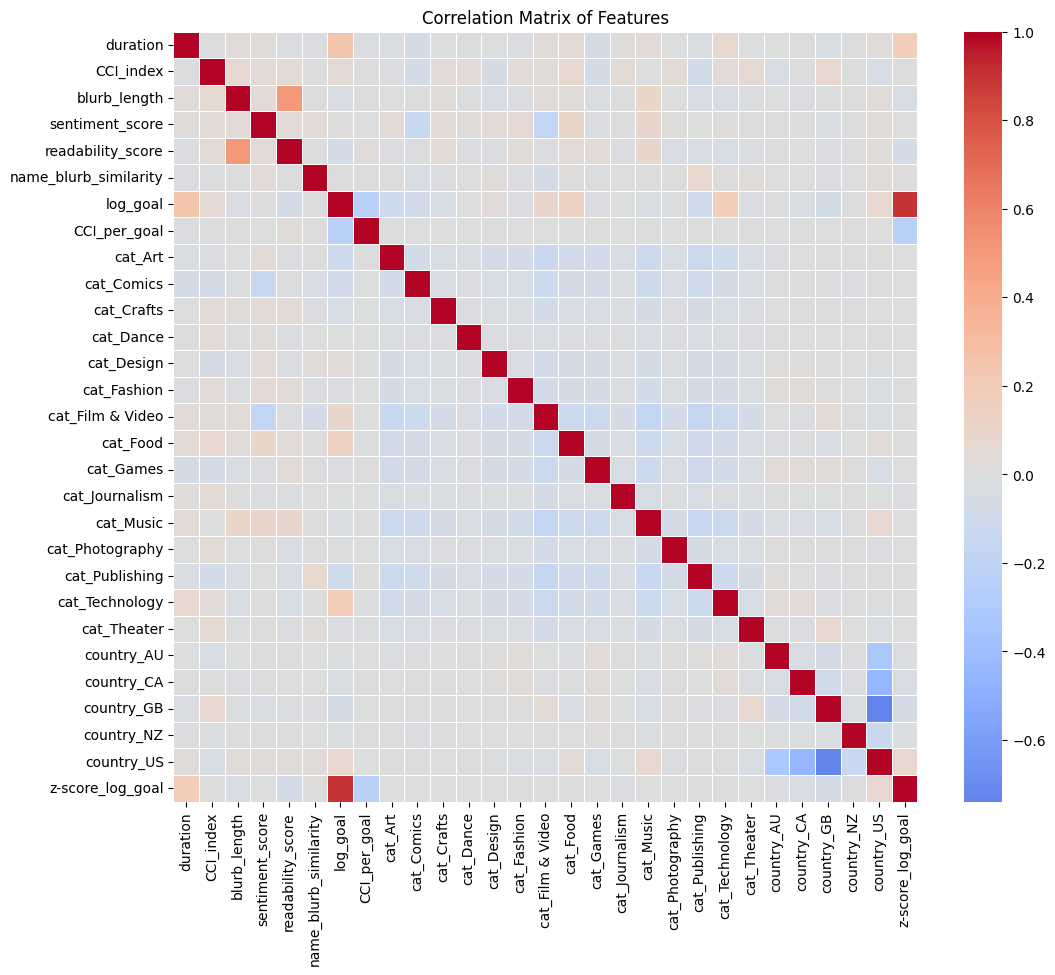

In [6]:
plt.figure(figsize=(12, 10))
corr_matrix = X_train_final.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

## Prediction with NLP features (only)

### Hyperparameter tuning

In [8]:
# RF GridSearch
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2
)
rf_grid.fit(X_train_final, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF parameters: {rf_grid.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.5s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.5s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.5s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.3s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.5s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.5s
[CV] END .max_depth=10, min_samples_leaf=5, n_es

In [9]:
# XGBoost GridSearch
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_final, y_train, 
    train_size=0.20, 
    stratify=y_train, 
    random_state=42
)

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)
xgb_grid.fit(X_train_sample, y_train_sample)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost parameters: {xgb_grid.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits


[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.7s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   2.5s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   2.5s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   2.5s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   2.5s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   2.6s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   2.6s
[CV] END ..learning_rate=0.0

### Model Training & Evaluation


--- Evaluating Logistic Regression (Lasso) ---
Training Accuracy : 0.718
Training F1-Score : 0.781
Training ROC-AUC  : 0.772

Test Accuracy : 0.717
Test F1-Score : 0.780
Test ROC-AUC  : 0.773





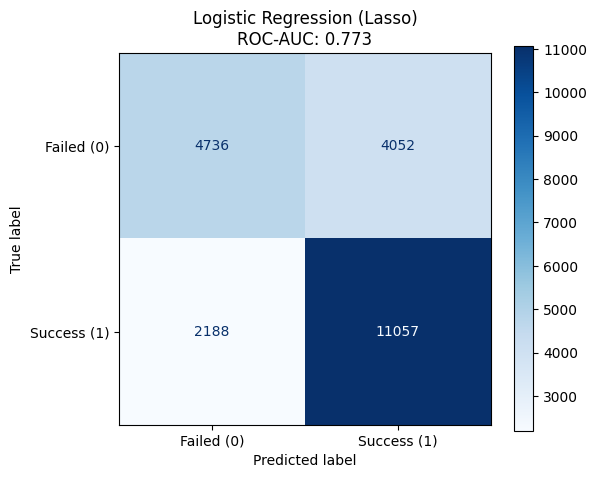


--- Evaluating Random Forest ---
Training Accuracy : 0.859
Training F1-Score : 0.892
Training ROC-AUC  : 0.946

Test Accuracy : 0.739
Test F1-Score : 0.799
Test ROC-AUC  : 0.807





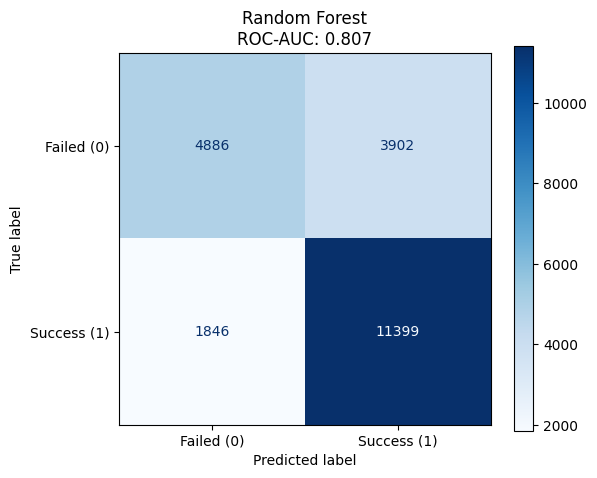


--- Evaluating XGBoost ---
Training Accuracy : 0.760
Training F1-Score : 0.813
Training ROC-AUC  : 0.834

Test Accuracy : 0.741
Test F1-Score : 0.798
Test ROC-AUC  : 0.812





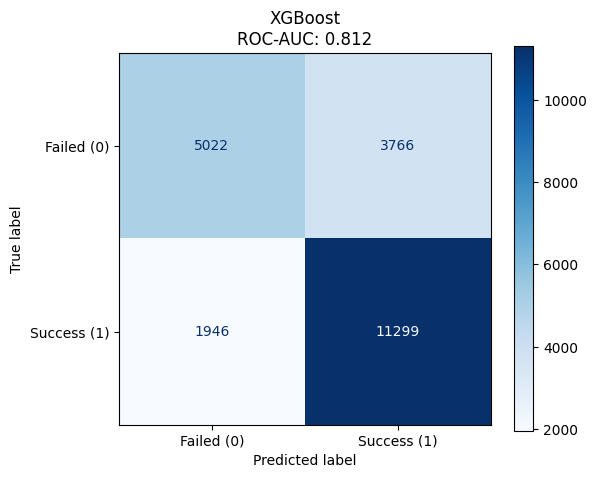

In [10]:
# models = {
#     "Logistic Regression (Lasso)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
#     "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# }

models = {
    "Logistic Regression (Lasso)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for idx, (name, model) in enumerate(models.items()):
    print(f"\n--- Evaluating {name} ---")
    
    model.fit(X_train_final, y_train)

    # Predictions on training set
    y_pred_train = model.predict(X_train_final)
    y_pred_proba_train = model.predict_proba(X_train_final)[:, 1]
    
    # # Predictions on validation set
    # y_pred_val = model.predict(X_val_final)
    # y_pred_proba_val = model.predict_proba(X_val_final)[:, 1]
    # Predictions on test set
    y_pred_test = model.predict(X_test_final)
    y_pred_proba_test = model.predict_proba(X_test_final)[:, 1]
    
    # Metrics on training set
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    auc_train = roc_auc_score(y_train, y_pred_proba_train)

    # # Metrics on validation set
    # acc_val = accuracy_score(y_val, y_pred_val)
    # f1_val = f1_score(y_val, y_pred_val)
    # auc_val = roc_auc_score(y_val, y_pred_proba_val)
    # Metrics on test set
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    auc_test = roc_auc_score(y_test, y_pred_proba_test)

    print(f"Training Accuracy : {acc_train:.3f}")
    print(f"Training F1-Score : {f1_train:.3f}")
    print(f"Training ROC-AUC  : {auc_train:.3f}\n")

    print(f"Test Accuracy : {acc_test:.3f}")
    print(f"Test F1-Score : {f1_test:.3f}")
    print(f"Test ROC-AUC  : {auc_test:.3f}\n")

    print("\n")
    
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5)) 
    
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Failed (0)", "Success (1)"])
    
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f"{name}\nROC-AUC: {auc_test:.3f}")
    
    plt.show()

## Feature Importance

### Global Feature Importance

In [11]:
rf_model = models["Random Forest"]
importances = best_rf.feature_importances_
feature_names = X_train_final.columns

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)
print("Most Important Features (Global) :")
print(df_importance.head(10))

Most Important Features (Global) :
                  Feature  Importance
7            CCI_per_goal    0.131959
1               CCI_index    0.122615
6                log_goal    0.117045
28       z-score_log_goal    0.104954
0                duration    0.100587
5   name_blurb_similarity    0.072793
4       readability_score    0.064122
3         sentiment_score    0.059128
15               cat_Food    0.038845
2            blurb_length    0.035129


### Local Feature Importance

In [12]:
# X_val_shap_sample = X_val_final.sample(n=100, random_state=42)
# y_val_shap_sample = y_val.loc[X_val_shap_sample.index]
X_test_shap_sample = X_test_final.sample(n=1000, random_state=42)
y_test_shap_sample = y_test.loc[X_test_shap_sample.index]

explainer = shap.TreeExplainer(best_rf)

shap_obj = explainer(X_test_shap_sample)


SHAP Explanation for the project 445 (from sample)
Category: Games
Name: Spellwards
Duration: 28 days
Goal: $1626.49125
Blurb: The word slinging card game. 2-10 minutes. 2-10 players. 1 minute teach. A thinky party game with beautiful art nouveau card designs
True class: 1
Predicted probability of success : 0.75


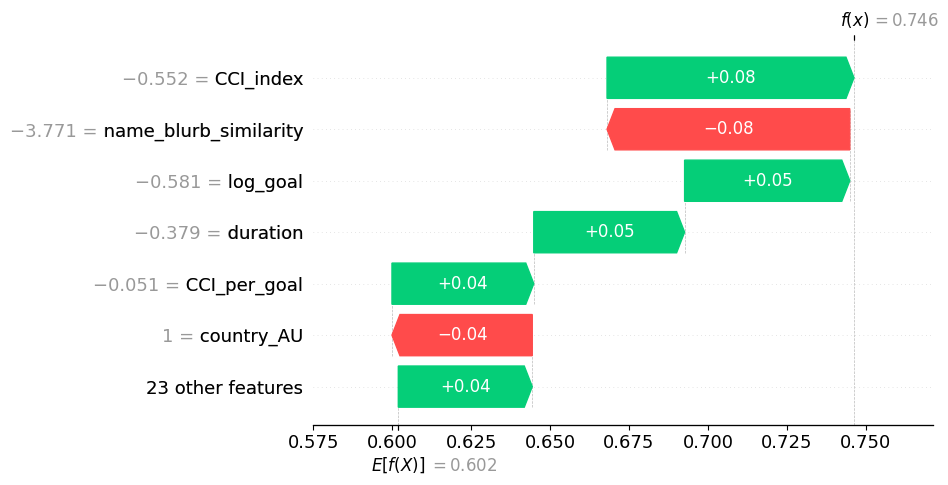

In [37]:
index_projet = 445
blurb_value = df_test.loc[X_test_shap_sample.index[index_projet], "blurb"]
category = df_test.loc[X_test_shap_sample.index[index_projet], "category.parent_name"]
name = df_test.loc[X_test_shap_sample.index[index_projet], "name"]
goal = df_test.loc[X_test_shap_sample.index[index_projet], "goal_usd"]
duration = df_test.loc[X_test_shap_sample.index[index_projet], "duration"]

print(f"\nSHAP Explanation for the project {index_projet} (from sample)")
print(f"Category: {category}")
print(f"Name: {name}")
print(f"Duration: {duration} days")
print(f"Goal: ${goal}")
print(f"Blurb: {blurb_value}")
print(f"True class: {y_test_shap_sample.iloc[index_projet]}")
print(f"Predicted probability of success : {best_rf.predict_proba(X_test_shap_sample.iloc[[index_projet]])[0][1]:.2f}")


shap.initjs()
shap.plots.waterfall(shap_obj[index_projet, :, 1], max_display=7, show=False)

fig = plt.gcf()

shap_red = "#ff0051"
shap_blue = "#008bfb"

ks_green = "#05ce78" 
ks_red = "#ff4b4b"   

for ax in fig.axes:
    
    for patch in ax.patches:
        face_color = mcolors.to_hex(patch.get_facecolor()) 
        
        if face_color == shap_red:
            patch.set_facecolor(ks_green)
            patch.set_edgecolor(ks_green)
        elif face_color == shap_blue:
            patch.set_facecolor(ks_red)
            patch.set_edgecolor(ks_red)
            
    for text in ax.texts:
        text_string_lower = text.get_text().lower()
        text_color = mcolors.to_hex(text.get_color())
        
        if text_color == shap_red:
            text.set_color(ks_green)
        elif text_color == shap_blue:
            text.set_color(ks_red)
            
        if "f(x)" in text_string_lower and "e[" not in text_string_lower:
            y_position = text.get_position()[1]
            if y_position < 0:
                text.set_text("")

plt.savefig(f"shap_kickstarter_proj_{index_projet}.png", transparent=False, dpi=300, bbox_inches='tight')
plt.show()